In [4]:
import pandas as pd

# Load the Excel file into a DataFrame
df = pd.read_excel('Cleaned_Inventory_use_data 1.xlsx')

# Display the first few rows of the DataFrame
df.head()

,Cluster_group,Product,Purchase_Date_Month,Amount
0,0.0,Fish,2012-01,501
1,NaN,NaN,2012-02,761
2,NaN,NaN,2012-03,424
3,NaN,NaN,2012-04,641
4,NaN,NaN,2012-05,385


In [5]:
df = df.rename(columns={'Purchase_Date_Month': 'Date', 'Amount': 'Total_Units_Sold'})
# Convert the 'Date' column to datetime objects
df['Date'] = pd.to_datetime(df['Date'])

# Set the 'Date' column as the DataFrame's index
df = df.set_index('Date')

# Group by 'Cluster_group' and 'Product', then resample to monthly frequency
monthly_sales = df.groupby(['Cluster_group', 'Product'])['Total_Units_Sold'].resample('MS').sum()

# Unstack, reindex to ensure all months are present, and stack back
# Fill any missing Total_Units_Sold values with 0
monthly_sales = monthly_sales.unstack(level=[0, 1]).asfreq('MS').stack(level=[0, 1],dropna=False).fillna(0)

# Reset index to convert 'Date' back to a column and rename the series to a column
monthly_sales = monthly_sales.reset_index(name='Total_Units_Sold')

# Display the first few rows of the processed DataFrame
print(monthly_sales.head())

print(monthly_sales.tail())

        Date  Cluster_group Product  Total_Units_Sold
0 2012-01-01            0.0    Fish               501
1 2012-01-01            1.0    Fish               135
2 2012-01-01            2.0    Fish              1788
        Date  Cluster_group Product  Total_Units_Sold
0 2012-01-01            0.0    Fish               501
1 2012-01-01            1.0    Fish               135
2 2012-01-01            2.0    Fish              1788


/tmp/ipython-input-1065968338.py:13: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  monthly_sales = monthly_sales.unstack(level=[0, 1]).asfreq('MS').stack(level=[0, 1],dropna=False).fillna(0)


In [6]:
import pandas as pd

# Group by 'Cluster_group' and 'Product', then resample to monthly frequency
# The 'df' DataFrame is already loaded and preprocessed (Date as index, Total_Units_Sold column) from previous steps.
monthly_sales = df.groupby(['Cluster_group', 'Product'])['Total_Units_Sold'].resample('MS').sum()

# Unstack, reindex to ensure all months are present, and stack back
# Fill any missing Total_Units_Sold values with 0
monthly_sales = monthly_sales.unstack(level=[0, 1]).asfreq('MS').stack(level=[0, 1], future_stack=True).fillna(0)

# Reset index to convert 'Date' back to a column and rename the series to a column
monthly_sales = monthly_sales.reset_index(name='Total_Units_Sold')

# Display the first few rows of the processed DataFrame
print(monthly_sales.head())

print(monthly_sales.tail())

        Date  Cluster_group Product  Total_Units_Sold
0 2012-01-01            0.0    Fish               501
1 2012-01-01            1.0    Fish               135
2 2012-01-01            2.0    Fish              1788
        Date  Cluster_group Product  Total_Units_Sold
0 2012-01-01            0.0    Fish               501
1 2012-01-01            1.0    Fish               135
2 2012-01-01            2.0    Fish              1788


In [7]:
import pandas as pd

# Group by 'Cluster_group' and 'Product', then resample to monthly frequency
# The 'df' DataFrame is already loaded and preprocessed (Date as index, Total_Units_Sold column) from previous steps.
monthly_sales = df.groupby(['Cluster_group', 'Product'])['Total_Units_Sold'].resample('MS').sum()

# Unstack, reindex to ensure all months are present, and stack back
# Fill any missing Total_Units_Sold values with 0
monthly_sales = monthly_sales.unstack(level=[0, 1]).asfreq('MS').stack(level=[0, 1], future_stack=True).fillna(0)

# Reset index to convert 'Date' back to a column and rename the series to a column
monthly_sales = monthly_sales.reset_index(name='Total_Units_Sold')

# Display the first few rows of the processed DataFrame
print(monthly_sales.head())

print(monthly_sales.tail())

        Date  Cluster_group Product  Total_Units_Sold
0 2012-01-01            0.0    Fish               501
1 2012-01-01            1.0    Fish               135
2 2012-01-01            2.0    Fish              1788
        Date  Cluster_group Product  Total_Units_Sold
0 2012-01-01            0.0    Fish               501
1 2012-01-01            1.0    Fish               135
2 2012-01-01            2.0    Fish              1788


In [8]:
from statsmodels.tsa.api import ExponentialSmoothing

monthly_sales['Date'] = pd.to_datetime(monthly_sales['Date'])
monthly_sales = monthly_sales.set_index('Date')

unique_combinations = monthly_sales[['Cluster_group', 'Product']].drop_duplicates()

forecasts_2015 = {}

for index, row in unique_combinations.iterrows():
    cluster = row['Cluster_group']
    product = row['Product']

    combo_data = monthly_sales[(monthly_sales['Cluster_group'] == cluster) & (monthly_sales['Product'] == product)]

    ts_data = combo_data['Total_Units_Sold']

    train_data = ts_data[ts_data.index.year <= 2014]

    seasonal_periods = 12

    best_model = None
    best_aic = float('inf')

    for trend_type in ['add', 'mul']:
        for seasonal_type in ['add', 'mul']:
            try:
                model = ExponentialSmoothing(train_data, trend=trend_type, seasonal=seasonal_type, seasonal_periods=seasonal_periods, initialization_method="estimated")
                fitted_model = model.fit(disp=False) # disp=False to suppress convergence messages
                if fitted_model.aic < best_aic:
                    best_aic = fitted_model.aic
                    best_model = fitted_model
            except Exception as e:
                # print(f"Skipping {cluster}-{product} with trend={trend_type}, seasonal={seasonal_type} due to error: {e}")
                pass # Sometimes 'mul' models fail for data with zeros or negative values

    if best_model:

        forecast = best_model.forecast(steps=12)

        forecasts_2015[(cluster, product)] = forecast

        print(f"Forecast for Cluster: {cluster}, Product: {product} generated.")
    else:
        print(f"Could not fit a suitable model for Cluster: {cluster}, Product: {product}.")

# Display a sample of the generated forecasts
print("\nSample of 2015 Forecasts:")
for (cluster, product), forecast_series in list(forecasts_2015.items())[:5]:
    print(f"Cluster: {cluster}, Product: {product}")
    print(forecast_series)
    print("\n")

Could not fit a suitable model for Cluster: 0.0, Product: Fish.
Could not fit a suitable model for Cluster: 1.0, Product: Fish.
Could not fit a suitable model for Cluster: 2.0, Product: Fish.

Sample of 2015 Forecasts:


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [9]:
from statsmodels.tsa.api import ExponentialSmoothing
import pandas as pd
import numpy as np

# The 'df' DataFrame is already loaded and has 'Date' as its index,
# but 'Cluster_group' and 'Product' columns still contain NaN values from the original Excel structure.
# Step 1: Fill NaN values in 'Cluster_group' and 'Product' with the last valid observation
df_cleaned = df.copy() # Work on a copy to avoid modifying original df in kernel for other potential uses if any
df_cleaned['Cluster_group'] = df_cleaned['Cluster_group'].ffill()
df_cleaned['Product'] = df_cleaned['Product'].ffill()

# Drop rows where Cluster_group or Product might still be NaN (e.g., if first few rows were NaN)
df_cleaned.dropna(subset=['Cluster_group', 'Product'], inplace=True)

# Convert Cluster_group to integer if it makes sense (after ffill and dropna)
df_cleaned['Cluster_group'] = df_cleaned['Cluster_group'].astype(int)

# Step 2: Resample to monthly frequency for each Cluster_group and Product
# This creates a MultiIndex Series with levels (Cluster_group, Product, Date)
monthly_sales_series = df_cleaned.groupby(['Cluster_group', 'Product'])['Total_Units_Sold'].resample('MS').sum()

# Step 3: Ensure all months are present for every combination and fill missing with zeros.
# Unstack the Product and Cluster_group levels to columns, making Date the index.
monthly_sales_unstacked = monthly_sales_series.unstack(level=[0, 1])

# Create a complete date range covering all dates in the original data
min_date = monthly_sales_series.index.get_level_values('Date').min()
max_date = monthly_sales_series.index.get_level_values('Date').max()
full_date_range = pd.date_range(start=min_date, end=max_date, freq='MS')

# Reindex the unstacked DataFrame to ensure all months are present, filling NaNs with 0
monthly_sales_reindexed = monthly_sales_unstacked.reindex(full_date_range, fill_value=0)

# Stack back to long format (Date, Cluster_group, Product as MultiIndex)
monthly_sales_final = monthly_sales_reindexed.stack(level=[0, 1], future_stack=True).to_frame(name='Total_Units_Sold')

# Reset the index to get Date, Cluster_group, Product as columns
monthly_sales = monthly_sales_final.reset_index()

# Rename the 'level_0' column to 'Date' which was created by reset_index
monthly_sales = monthly_sales.rename(columns={'level_0': 'Date'})

# Set 'Date' as the DataFrame index for time series operations for the forecasting step
monthly_sales = monthly_sales.set_index('Date')

# Identify all unique combinations of 'Cluster_group' and 'Product' from the corrected monthly_sales
unique_combinations = monthly_sales[['Cluster_group', 'Product']].drop_duplicates()

# Dictionary to store forecasts for 2015
forecasts_2015 = {}

# Determine seasonal periods (e.g., 12 for monthly data)
seasonal_periods = 12

# Loop through each unique combination
for index, row in unique_combinations.iterrows():
    cluster = row['Cluster_group']
    product = row['Product']

    # Filter data for the current combination
    combo_data = monthly_sales[(monthly_sales['Cluster_group'] == cluster) & (monthly_sales['Product'] == product)]

    # Select the 'Total_Units_Sold' and ensure it's a Series indexed by Date
    ts_data = combo_data['Total_Units_Sold']

    # Split data into training set (up to end of 2014)
    train_data = ts_data[ts_data.index.year <= 2014]

    # Add a frequency to the time series index for statsmodels to prevent ValueWarning
    train_data = train_data.asfreq('MS') # 'MS' for Month Start frequency

    # Check if train_data is empty or too short for seasonal model
    if len(train_data) < seasonal_periods * 2: # At least two full seasons for a good seasonal model
        print(f"Skipping Cluster: {cluster}, Product: {product} due to insufficient training data ({len(train_data)} data points).")
        continue

    # Apply Winter's Model (Triple Exponential Smoothing) with auto-optimization for parameters
    best_model = None
    best_aic = float('inf')

    for trend_type in ['add', 'mul']:
        for seasonal_type in ['add', 'mul']:
            try:
                # 'mul' seasonal type often fails with zero values. Handle this.
                if seasonal_type == 'mul' and (train_data == 0).any():
                    continue

                model = ExponentialSmoothing(train_data, trend=trend_type, seasonal=seasonal_type,
                                             seasonal_periods=seasonal_periods, initialization_method="estimated")
                fitted_model = model.fit(disp=False) # disp=False to suppress convergence messages
                if fitted_model.aic is not None and fitted_model.aic < best_aic:
                    best_aic = fitted_model.aic
                    best_model = fitted_model
            except Exception as e:
                # print(f"Skipping {cluster}-{product} with trend={trend_type}, seasonal={seasonal_type} due to error: {e}")
                pass # Sometimes models fail (e.g., 'mul' with zeros or insufficient data for certain trend/seasonal)

    if best_model:
        # Generate forecasts for 12 months of 2015
        forecast = best_model.forecast(steps=12)

        # Store the forecast with cluster and product information
        forecasts_2015[(cluster, product)] = forecast

        print(f"Forecast for Cluster: {cluster}, Product: {product} generated. Best AIC: {best_aic:.2f}")
    else:
        print(f"Could not fit a suitable model for Cluster: {cluster}, Product: {product} after trying all combinations.")

# Display a sample of the generated forecasts
print("\nSample of 2015 Forecasts:")
if forecasts_2015:
    for (cluster, product), forecast_series in list(forecasts_2015.items())[:5]:
        print(f"Cluster: {cluster}, Product: {product}")
        print(forecast_series)
        print("\n")
else:
    print("No forecasts were generated.")

Could not fit a suitable model for Cluster: 0, Product: Fish after trying all combinations.
Could not fit a suitable model for Cluster: 0, Product: Fruits after trying all combinations.
Could not fit a suitable model for Cluster: 0, Product: Gold after trying all combinations.
Could not fit a suitable model for Cluster: 0, Product: Meat after trying all combinations.
Could not fit a suitable model for Cluster: 0, Product: Wines after trying all combinations.
Could not fit a suitable model for Cluster: 1, Product: Fish after trying all combinations.
Could not fit a suitable model for Cluster: 1, Product: Fruits after trying all combinations.
Could not fit a suitable model for Cluster: 1, Product: Gold after trying all combinations.
Could not fit a suitable model for Cluster: 1, Product: Meat after trying all combinations.
Could not fit a suitable model for Cluster: 1, Product: Wines after trying all combinations.
Could not fit a suitable model for Cluster: 2, Product: Fish after trying 

In [10]:
from statsmodels.tsa.api import ExponentialSmoothing
import pandas as pd
import numpy as np

# The 'df' DataFrame is already loaded and has 'Date' as its index,
# but 'Cluster_group' and 'Product' columns still contain NaN values from the original Excel structure.
# Step 1: Fill NaN values in 'Cluster_group' and 'Product' with the last valid observation
df_cleaned = df.copy() # Work on a copy to avoid modifying original df in kernel for other potential uses if any
df_cleaned['Cluster_group'] = df_cleaned['Cluster_group'].ffill()
df_cleaned['Product'] = df_cleaned['Product'].ffill()

# Drop rows where Cluster_group or Product might still be NaN (e.g., if first few rows were NaN)
df_cleaned.dropna(subset=['Cluster_group', 'Product'], inplace=True)

# Convert Cluster_group to integer if it makes sense (after ffill and dropna)
df_cleaned['Cluster_group'] = df_cleaned['Cluster_group'].astype(int)

# Step 2: Resample to monthly frequency for each Cluster_group and Product
# This creates a MultiIndex Series with levels (Cluster_group, Product, Date)
monthly_sales_series = df_cleaned.groupby(['Cluster_group', 'Product'])['Total_Units_Sold'].resample('MS').sum()

# Step 3: Ensure all months are present for every combination and fill missing with zeros.
# Unstack the Product and Cluster_group levels to columns, making Date the index.
monthly_sales_unstacked = monthly_sales_series.unstack(level=[0, 1])

# Create a complete date range covering all dates in the original data
min_date = monthly_sales_series.index.get_level_values('Date').min()
max_date = monthly_sales_series.index.get_level_values('Date').max()
full_date_range = pd.date_range(start=min_date, end=max_date, freq='MS')

# Reindex the unstacked DataFrame to ensure all months are present, filling NaNs with 0
monthly_sales_reindexed = monthly_sales_unstacked.reindex(full_date_range, fill_value=0)

# Stack back to long format (Date, Cluster_group, Product as MultiIndex)
monthly_sales_final = monthly_sales_reindexed.stack(level=[0, 1], future_stack=True).to_frame(name='Total_Units_Sold')

# Reset the index to get Date, Cluster_group, Product as columns
monthly_sales = monthly_sales_final.reset_index()

# Rename the 'level_0' column to 'Date' which was created by reset_index
monthly_sales = monthly_sales.rename(columns={'level_0': 'Date'})

# Set 'Date' as the DataFrame index for time series operations for the forecasting step
monthly_sales = monthly_sales.set_index('Date')

# Identify all unique combinations of 'Cluster_group' and 'Product' from the corrected monthly_sales
unique_combinations = monthly_sales[['Cluster_group', 'Product']].drop_duplicates()

# Dictionary to store forecasts for 2015
forecasts_2015 = {}

# Determine seasonal periods (e.g., 12 for monthly data)
seasonal_periods = 12

# Loop through each unique combination
for index, row in unique_combinations.iterrows():
    cluster = row['Cluster_group']
    product = row['Product']

    # Filter data for the current combination
    combo_data = monthly_sales[(monthly_sales['Cluster_group'] == cluster) & (monthly_sales['Product'] == product)]

    # Select the 'Total_Units_Sold' and ensure it's a Series indexed by Date
    ts_data = combo_data['Total_Units_Sold']

    # Split data into training set (up to end of 2014)
    train_data = ts_data[ts_data.index.year <= 2014]

    # Add a frequency to the time series index for statsmodels to prevent ValueWarning
    train_data = train_data.asfreq('MS') # 'MS' for Month Start frequency

    # Check if train_data is empty or too short for seasonal model
    if len(train_data) < seasonal_periods * 2: # At least two full seasons for a good seasonal model
        print(f"Skipping Cluster: {cluster}, Product: {product} due to insufficient training data ({len(train_data)} data points).")
        continue

    # Handle cases where training data is all zeros
    if (train_data == 0).all():
        print(f"Forecast for Cluster: {cluster}, Product: {product} is all zeros due to zero training data.")
        # Create a series of zeros for the 12 months of 2015
        forecast = pd.Series(0.0, index=pd.date_range(start='2015-01-01', periods=12, freq='MS'))
        forecasts_2015[(cluster, product)] = forecast
        continue

    # Apply Winter's Model (Triple Exponential Smoothing) with auto-optimization for parameters
    best_model = None
    best_aic = float('inf')

    for trend_type in ['add', 'mul']:
        for seasonal_type in ['add', 'mul']:
            try:
                # 'mul' seasonal type often fails with zero values. Handle this more robustly.
                # If using multiplicative components, all values must be strictly positive.
                if (seasonal_type == 'mul' or trend_type == 'mul') and (train_data <= 0).any():
                    continue # Skip multiplicative models if data contains non-positive values

                model = ExponentialSmoothing(train_data, trend=trend_type, seasonal=seasonal_type,
                                             seasonal_periods=seasonal_periods, initialization_method="estimated")
                fitted_model = model.fit(disp=False) # disp=False to suppress convergence messages

                # Ensure AIC is a valid number before comparison
                if fitted_model.aic is not None and not np.isinf(fitted_model.aic) and fitted_model.aic < best_aic:
                    best_aic = fitted_model.aic
                    best_model = fitted_model
            except Exception as e:
                # print(f"Skipping {cluster}-{product} with trend={trend_type}, seasonal={seasonal_type} due to error: {e}")
                pass # Sometimes models fail (e.g., 'mul' with zeros or insufficient data for certain trend/seasonal)

    if best_model:
        # Generate forecasts for 12 months of 2015
        forecast = best_model.forecast(steps=12)

        # Store the forecast with cluster and product information
        forecasts_2015[(cluster, product)] = forecast

        print(f"Forecast for Cluster: {cluster}, Product: {product} generated. Best AIC: {best_aic:.2f}")
    else:
        print(f"Could not fit a suitable model for Cluster: {cluster}, Product: {product} after trying all combinations.")

# Display a sample of the generated forecasts
print("\nSample of 2015 Forecasts:")
if forecasts_2015:
    # Convert forecasts_2015 to a DataFrame for better display and further processing
    forecasts_df = pd.DataFrame(
        [
            {
                'Cluster_group': k[0],
                'Product': k[1],
                'Date': date,
                'Forecast_Units_Sold': v[date]
            }
            for k, v_series in forecasts_2015.items()
            for date in v_series.index
        ]
    )
    # Pivot to get Dates as columns for each combination
    forecasts_pivot = forecasts_df.pivot_table(index=['Cluster_group', 'Product'], columns='Date', values='Forecast_Units_Sold')
    print(forecasts_pivot.head())
else:
    print("No forecasts were generated.")

Could not fit a suitable model for Cluster: 0, Product: Fish after trying all combinations.
Could not fit a suitable model for Cluster: 0, Product: Fruits after trying all combinations.
Could not fit a suitable model for Cluster: 0, Product: Gold after trying all combinations.
Could not fit a suitable model for Cluster: 0, Product: Meat after trying all combinations.
Could not fit a suitable model for Cluster: 0, Product: Wines after trying all combinations.
Could not fit a suitable model for Cluster: 1, Product: Fish after trying all combinations.
Could not fit a suitable model for Cluster: 1, Product: Fruits after trying all combinations.
Could not fit a suitable model for Cluster: 1, Product: Gold after trying all combinations.
Could not fit a suitable model for Cluster: 1, Product: Meat after trying all combinations.
Could not fit a suitable model for Cluster: 1, Product: Wines after trying all combinations.
Could not fit a suitable model for Cluster: 2, Product: Fish after trying 

In [11]:
from statsmodels.tsa.api import ExponentialSmoothing
import pandas as pd
import numpy as np

# The 'df' DataFrame is already loaded and has 'Date' as its index,
# but 'Cluster_group' and 'Product' columns still contain NaN values from the original Excel structure.
# Step 1: Fill NaN values in 'Cluster_group' and 'Product' with the last valid observation
df_cleaned = df.copy() # Work on a copy to avoid modifying original df in kernel for other potential uses if any
df_cleaned['Cluster_group'] = df_cleaned['Cluster_group'].ffill()
df_cleaned['Product'] = df_cleaned['Product'].ffill()

# Drop rows where Cluster_group or Product might still be NaN (e.g., if first few rows were NaN)
df_cleaned.dropna(subset=['Cluster_group', 'Product'], inplace=True)

# Convert Cluster_group to integer if it makes sense (after ffill and dropna)
df_cleaned['Cluster_group'] = df_cleaned['Cluster_group'].astype(int)

# Step 2: Resample to monthly frequency for each Cluster_group and Product
# This creates a MultiIndex Series with levels (Cluster_group, Product, Date)
monthly_sales_series = df_cleaned.groupby(['Cluster_group', 'Product'])['Total_Units_Sold'].resample('MS').sum()

# Step 3: Ensure all months are present for every combination and fill missing with zeros.
# Unstack the Product and Cluster_group levels to columns, making Date the index.
monthly_sales_unstacked = monthly_sales_series.unstack(level=[0, 1])

# Create a complete date range covering all dates in the original data
min_date = monthly_sales_series.index.get_level_values('Date').min()
max_date = monthly_sales_series.index.get_level_values('Date').max()
full_date_range = pd.date_range(start=min_date, end=max_date, freq='MS')

# Reindex the unstacked DataFrame to ensure all months are present, filling NaNs with 0
monthly_sales_reindexed = monthly_sales_unstacked.reindex(full_date_range, fill_value=0)

# Stack back to long format (Date, Cluster_group, Product as MultiIndex)
monthly_sales_final = monthly_sales_reindexed.stack(level=[0, 1], future_stack=True).to_frame(name='Total_Units_Sold')

# Reset the index to get Date, Cluster_group, Product as columns
monthly_sales = monthly_sales_final.reset_index()

# Rename the 'level_0' column to 'Date' which was created by reset_index
monthly_sales = monthly_sales.rename(columns={'level_0': 'Date'})

# Set 'Date' as the DataFrame index for time series operations for the forecasting step
monthly_sales = monthly_sales.set_index('Date')

# Identify all unique combinations of 'Cluster_group' and 'Product' from the corrected monthly_sales
unique_combinations = monthly_sales[['Cluster_group', 'Product']].drop_duplicates()

# Dictionary to store forecasts for 2015
forecasts_2015 = {}

# Determine seasonal periods (e.g., 12 for monthly data)
seasonal_periods = 12

# Loop through each unique combination
for index, row in unique_combinations.iterrows():
    cluster = row['Cluster_group']
    product = row['Product']

    # Filter data for the current combination
    combo_data = monthly_sales[(monthly_sales['Cluster_group'] == cluster) & (monthly_sales['Product'] == product)]

    # Select the 'Total_Units_Sold' and ensure it's a Series indexed by Date
    ts_data = combo_data['Total_Units_Sold']

    # Split data into training set (up to end of 2014)
    train_data = ts_data[ts_data.index.year <= 2014]

    # Add a frequency to the time series index for statsmodels to prevent ValueWarning
    train_data = train_data.asfreq('MS') # 'MS' for Month Start frequency

    # Check if train_data is empty or too short for seasonal model
    if len(train_data) < seasonal_periods * 2: # At least two full seasons for a good seasonal model
        print(f"Skipping Cluster: {cluster}, Product: {product} due to insufficient training data ({len(train_data)} data points).")
        continue

    # Handle cases where training data is all zeros
    if (train_data == 0).all():
        print(f"Forecast for Cluster: {cluster}, Product: {product} is all zeros due to zero training data.")
        # Create a series of zeros for the 12 months of 2015
        forecast = pd.Series(0.0, index=pd.date_range(start='2015-01-01', periods=12, freq='MS'))
        forecasts_2015[(cluster, product)] = forecast
        continue

    # Check if train_data has no variance (all values are the same and non-zero)
    if train_data.nunique() == 1 and not (train_data == 0).all():
        print(f"Forecast for Cluster: {cluster}, Product: {product} is constant due to invariant training data.")
        # Forecast the constant value for 2015
        forecast = pd.Series(train_data.iloc[0], index=pd.date_range(start='2015-01-01', periods=12, freq='MS'))
        forecasts_2015[(cluster, product)] = forecast
        continue


    # Apply Winter's Model (Triple Exponential Smoothing) with auto-optimization for parameters
    best_model = None
    best_aic = float('inf')

    # Store errors for each model type
    model_errors = {}

    for trend_type in ['add', 'mul']:
        for seasonal_type in ['add', 'mul']:
            try:
                # 'mul' seasonal type often fails with zero values. Handle this more robustly.
                # If using multiplicative components, all values must be strictly positive.
                if (seasonal_type == 'mul' or trend_type == 'mul') and (train_data <= 0).any():
                    model_errors[(trend_type, seasonal_type)] = "Multiplicative model requires strictly positive data."
                    continue # Skip multiplicative models if data contains non-positive values

                # For non-zero but possibly low variance data, 'mul' models might still struggle
                # If train_data variance is very low, 'add' might be more stable.
                # This is implicitly handled by AIC selection, but can be a source of errors.

                model = ExponentialSmoothing(train_data, trend=trend_type, seasonal=seasonal_type,
                                             seasonal_periods=seasonal_periods, initialization_method="estimated")
                fitted_model = model.fit(disp=False) # disp=False to suppress convergence messages

                # Ensure AIC is a valid number before comparison
                if fitted_model.aic is not None and not np.isinf(fitted_model.aic) and fitted_model.aic < best_aic:
                    best_aic = fitted_model.aic
                    best_model = fitted_model
            except Exception as e:
                model_errors[(trend_type, seasonal_type)] = str(e)
                # print(f"Error fitting {trend_type}-{seasonal_type} for {cluster}-{product}: {e}")
                pass # Continue to try other model types even if one fails

    if best_model:
        # Generate forecasts for 12 months of 2015
        forecast = best_model.forecast(steps=12)

        # Store the forecast with cluster and product information
        forecasts_2015[(cluster, product)] = forecast

        print(f"Forecast for Cluster: {cluster}, Product: {product} generated. Best AIC: {best_aic:.2f}")
    else:
        print(f"Could not fit a suitable model for Cluster: {cluster}, Product: {product} after trying all combinations. Errors: {model_errors}")

# Display a sample of the generated forecasts
print("\nSample of 2015 Forecasts:")
if forecasts_2015:
    # Convert forecasts_2015 to a DataFrame for better display and further processing
    forecasts_df = pd.DataFrame(
        [
            {
                'Cluster_group': k[0],
                'Product': k[1],
                'Date': date,
                'Forecast_Units_Sold': v[date]
            }
            for k, v_series in forecasts_2015.items()
            for date in v_series.index
        ]
    )
    # Pivot to get Dates as columns for each combination
    forecasts_pivot = forecasts_df.pivot_table(index=['Cluster_group', 'Product'], columns='Date', values='Forecast_Units_Sold')
    print(forecasts_pivot.head())
else:
    print("No forecasts were generated.")

Could not fit a suitable model for Cluster: 0, Product: Fish after trying all combinations. Errors: {('add', 'add'): "ExponentialSmoothing.fit() got an unexpected keyword argument 'disp'", ('add', 'mul'): "ExponentialSmoothing.fit() got an unexpected keyword argument 'disp'", ('mul', 'add'): "ExponentialSmoothing.fit() got an unexpected keyword argument 'disp'", ('mul', 'mul'): "ExponentialSmoothing.fit() got an unexpected keyword argument 'disp'"}
Could not fit a suitable model for Cluster: 0, Product: Fruits after trying all combinations. Errors: {('add', 'add'): "ExponentialSmoothing.fit() got an unexpected keyword argument 'disp'", ('add', 'mul'): "ExponentialSmoothing.fit() got an unexpected keyword argument 'disp'", ('mul', 'add'): "ExponentialSmoothing.fit() got an unexpected keyword argument 'disp'", ('mul', 'mul'): "ExponentialSmoothing.fit() got an unexpected keyword argument 'disp'"}
Could not fit a suitable model for Cluster: 0, Product: Gold after trying all combinations. 

In [12]:
from statsmodels.tsa.api import ExponentialSmoothing
import pandas as pd
import numpy as np

# The 'df' DataFrame is already loaded and has 'Date' as its index,
# but 'Cluster_group' and 'Product' columns still contain NaN values from the original Excel structure.
# Step 1: Fill NaN values in 'Cluster_group' and 'Product' with the last valid observation
df_cleaned = df.copy() # Work on a copy to avoid modifying original df in kernel for other potential uses if any
df_cleaned['Cluster_group'] = df_cleaned['Cluster_group'].ffill()
df_cleaned['Product'] = df_cleaned['Product'].ffill()

# Drop rows where Cluster_group or Product might still be NaN (e.g., if first few rows were NaN)
df_cleaned.dropna(subset=['Cluster_group', 'Product'], inplace=True)

# Convert Cluster_group to integer if it makes sense (after ffill and dropna)
df_cleaned['Cluster_group'] = df_cleaned['Cluster_group'].astype(int)

# Step 2: Resample to monthly frequency for each Cluster_group and Product
# This creates a MultiIndex Series with levels (Cluster_group, Product, Date)
monthly_sales_series = df_cleaned.groupby(['Cluster_group', 'Product'])['Total_Units_Sold'].resample('MS').sum()

# Step 3: Ensure all months are present for every combination and fill missing with zeros.
# Unstack the Product and Cluster_group levels to columns, making Date the index.
monthly_sales_unstacked = monthly_sales_series.unstack(level=[0, 1])

# Create a complete date range covering all dates in the original data
min_date = monthly_sales_series.index.get_level_values('Date').min()
max_date = monthly_sales_series.index.get_level_values('Date').max()
full_date_range = pd.date_range(start=min_date, end=max_date, freq='MS')

# Reindex the unstacked DataFrame to ensure all months are present, filling NaNs with 0
monthly_sales_reindexed = monthly_sales_unstacked.reindex(full_date_range, fill_value=0)

# Stack back to long format (Date, Cluster_group, Product as MultiIndex)
monthly_sales_final = monthly_sales_reindexed.stack(level=[0, 1], future_stack=True).to_frame(name='Total_Units_Sold')

# Reset the index to get Date, Cluster_group, Product as columns
monthly_sales = monthly_sales_final.reset_index()

# Rename the 'level_0' column to 'Date' which was created by reset_index
monthly_sales = monthly_sales.rename(columns={'level_0': 'Date'})

# Set 'Date' as the DataFrame index for time series operations for the forecasting step
monthly_sales = monthly_sales.set_index('Date')

# Identify all unique combinations of 'Cluster_group' and 'Product' from the corrected monthly_sales
unique_combinations = monthly_sales[['Cluster_group', 'Product']].drop_duplicates()

# Dictionary to store forecasts for 2015
forecasts_2015 = {}

# Determine seasonal periods (e.g., 12 for monthly data)
seasonal_periods = 12

# Loop through each unique combination
for index, row in unique_combinations.iterrows():
    cluster = row['Cluster_group']
    product = row['Product']

    # Filter data for the current combination
    combo_data = monthly_sales[(monthly_sales['Cluster_group'] == cluster) & (monthly_sales['Product'] == product)]

    # Select the 'Total_Units_Sold' and ensure it's a Series indexed by Date
    ts_data = combo_data['Total_Units_Sold']

    # Split data into training set (up to end of 2014)
    train_data = ts_data[ts_data.index.year <= 2014]

    # Add a frequency to the time series index for statsmodels to prevent ValueWarning
    train_data = train_data.asfreq('MS') # 'MS' for Month Start frequency

    # Check if train_data is empty or too short for seasonal model
    if len(train_data) < seasonal_periods * 2: # At least two full seasons for a good seasonal model
        print(f"Skipping Cluster: {cluster}, Product: {product} due to insufficient training data ({len(train_data)} data points).")
        continue

    # Handle cases where training data is all zeros
    if (train_data == 0).all():
        print(f"Forecast for Cluster: {cluster}, Product: {product} is all zeros due to zero training data.")
        # Create a series of zeros for the 12 months of 2015
        forecast = pd.Series(0.0, index=pd.date_range(start='2015-01-01', periods=12, freq='MS'))
        forecasts_2015[(cluster, product)] = forecast
        continue

    # Check if train_data has no variance (all values are the same and non-zero)
    if train_data.nunique() == 1 and not (train_data == 0).all():
        print(f"Forecast for Cluster: {cluster}, Product: {product} is constant due to invariant training data.")
        # Forecast the constant value for 2015
        forecast = pd.Series(train_data.iloc[0], index=pd.date_range(start='2015-01-01', periods=12, freq='MS'))
        forecasts_2015[(cluster, product)] = forecast
        continue


    # Apply Winter's Model (Triple Exponential Smoothing) with auto-optimization for parameters
    best_model = None
    best_aic = float('inf')

    # Store errors for each model type
    model_errors = {}

    for trend_type in ['add', 'mul']:
        for seasonal_type in ['add', 'mul']:
            try:
                # 'mul' seasonal type often fails with zero values. Handle this more robustly.
                # If using multiplicative components, all values must be strictly positive.
                if (seasonal_type == 'mul' or trend_type == 'mul') and (train_data <= 0).any():
                    model_errors[(trend_type, seasonal_type)] = "Multiplicative model requires strictly positive data."
                    continue # Skip multiplicative models if data contains non-positive values

                # For non-zero but possibly low variance data, 'mul' models might still struggle
                # If train_data variance is very low, 'add' might be more stable.
                # This is implicitly handled by AIC selection, but can be a source of errors.

                model = ExponentialSmoothing(train_data, trend=trend_type, seasonal=seasonal_type,
                                             seasonal_periods=seasonal_periods, initialization_method="estimated")
                fitted_model = model.fit() # Removed disp=False

                # Ensure AIC is a valid number before comparison
                if fitted_model.aic is not None and not np.isinf(fitted_model.aic) and fitted_model.aic < best_aic:
                    best_aic = fitted_model.aic
                    best_model = fitted_model
            except Exception as e:
                model_errors[(trend_type, seasonal_type)] = str(e)
                # print(f"Error fitting {trend_type}-{seasonal_type} for {cluster}-{product}: {e}")
                pass # Continue to try other model types even if one fails

    if best_model:
        # Generate forecasts for 12 months of 2015
        forecast = best_model.forecast(steps=12)

        # Store the forecast with cluster and product information
        forecasts_2015[(cluster, product)] = forecast

        print(f"Forecast for Cluster: {cluster}, Product: {product} generated. Best AIC: {best_aic:.2f}")
    else:
        print(f"Could not fit a suitable model for Cluster: {cluster}, Product: {product} after trying all combinations. Errors: {model_errors}")

# Display a sample of the generated forecasts
print("\nSample of 2015 Forecasts:")
if forecasts_2015:
    # Convert forecasts_2015 to a DataFrame for better display and further processing
    forecasts_df = pd.DataFrame(
        [
            {
                'Cluster_group': k[0],
                'Product': k[1],
                'Date': date,
                'Forecast_Units_Sold': v_series[date] # Corrected from v[date] to v_series[date]
            }
            for k, v_series in forecasts_2015.items()
            for date in v_series.index
        ]
    )
    # Pivot to get Dates as columns for each combination
    forecasts_pivot = forecasts_df.pivot_table(index=['Cluster_group', 'Product'], columns='Date', values='Forecast_Units_Sold')
    print(forecasts_pivot.head())
else:
    print("No forecasts were generated.")

Forecast for Cluster: 0, Product: Fish generated. Best AIC: 366.30
Forecast for Cluster: 0, Product: Fruits generated. Best AIC: 371.68
Forecast for Cluster: 0, Product: Gold generated. Best AIC: 412.15
Forecast for Cluster: 0, Product: Meat generated. Best AIC: 453.13
Forecast for Cluster: 0, Product: Wines generated. Best AIC: 541.57
Forecast for Cluster: 1, Product: Fish generated. Best AIC: 310.28
Forecast for Cluster: 1, Product: Fruits generated. Best AIC: 268.52
Forecast for Cluster: 1, Product: Gold generated. Best AIC: 360.39
Forecast for Cluster: 1, Product: Meat generated. Best AIC: 404.53


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


Forecast for Cluster: 1, Product: Wines generated. Best AIC: 402.19
Forecast for Cluster: 2, Product: Fish generated. Best AIC: 434.91
Forecast for Cluster: 2, Product: Fruits generated. Best AIC: 404.58
Forecast for Cluster: 2, Product: Gold generated. Best AIC: 414.51
Forecast for Cluster: 2, Product: Meat generated. Best AIC: 512.64
Forecast for Cluster: 2, Product: Wines generated. Best AIC: 544.79

Sample of 2015 Forecasts:
Date                    2015-01-01   2015-02-01   2015-03-01   2015-04-01  \
Cluster_group Product                                                       
0             Fish      376.130917   492.652451   432.875714   488.117810   
              Fruits    456.762436   271.759662   403.425543   415.422147   
              Gold      809.336193   807.998338  1000.999463   975.667509   
              Meat     2467.972523  1782.314985  2282.629216  2325.653943   
              Wines    6552.005665  5853.987208  5393.526908  6147.983424   

Date                    201

In [13]:
from statsmodels.tsa.api import SimpleExpSmoothing, Holt

# Dictionary to store forecasts for 2015 from Double Exponential Smoothing
forecasts_2015_des = {}

# Loop through each unique combination
for index, row in unique_combinations.iterrows():
    cluster = row['Cluster_group']
    product = row['Product']

    # Filter data for the current combination
    combo_data = monthly_sales[(monthly_sales['Cluster_group'] == cluster) & (monthly_sales['Product'] == product)]

    # Select the 'Total_Units_Sold' and ensure it's a Series indexed by Date
    ts_data = combo_data['Total_Units_Sold']

    # Split data into training set (up to end of 2014)
    train_data = ts_data[ts_data.index.year <= 2014]

    # Add a frequency to the time series index for statsmodels to prevent ValueWarning
    train_data = train_data.asfreq('MS') # 'MS' for Month Start frequency

    # Check if train_data is empty or too short for a trend model
    if len(train_data) < 2: # At least two data points for trend
        print(f"Skipping Cluster: {cluster}, Product: {product} for DES due to insufficient training data ({len(train_data)} data points).")
        continue

    # Handle cases where training data is all zeros
    if (train_data == 0).all():
        print(f"DES Forecast for Cluster: {cluster}, Product: {product} is all zeros due to zero training data.")
        forecast = pd.Series(0.0, index=pd.date_range(start='2015-01-01', periods=12, freq='MS'))
        forecasts_2015_des[(cluster, product)] = forecast
        continue

    # Check if train_data has no variance (all values are the same and non-zero)
    if train_data.nunique() == 1 and not (train_data == 0).all():
        print(f"DES Forecast for Cluster: {cluster}, Product: {product} is constant due to invariant training data.")
        forecast = pd.Series(train_data.iloc[0], index=pd.date_range(start='2015-01-01', periods=12, freq='MS'))
        forecasts_2015_des[(cluster, product)] = forecast
        continue

    # Apply Double Exponential Smoothing (Holt's Linear Trend Model)
    # Experimenting with 'add' and 'mul' for trend components
    best_model_des = None
    best_aic_des = float('inf')

    # Store errors for each model type
    model_errors_des = {}

    for trend_type in ['add', 'mul']:
        try:
            # 'mul' trend type often fails with zero values. Handle this.
            if trend_type == 'mul' and (train_data <= 0).any():
                model_errors_des[trend_type] = "Multiplicative trend requires strictly positive data."
                continue # Skip multiplicative trend if data contains non-positive values

            model_des = Holt(train_data, exponential=(trend_type == 'mul'), initialization_method="estimated")
            fitted_model_des = model_des.fit()

            # Ensure AIC is a valid number before comparison
            if fitted_model_des.aic is not None and not np.isinf(fitted_model_des.aic) and fitted_model_des.aic < best_aic_des:
                best_aic_des = fitted_model_des.aic
                best_model_des = fitted_model_des
        except Exception as e:
            model_errors_des[trend_type] = str(e)
            pass # Continue to try other model types even if one fails

    if best_model_des:
        # Generate forecasts for 12 months of 2015
        forecast_des = best_model_des.forecast(steps=12)

        # Store the forecast with cluster and product information
        forecasts_2015_des[(cluster, product)] = forecast_des

        print(f"DES Forecast for Cluster: {cluster}, Product: {product} generated. Best AIC: {best_aic_des:.2f}")
    else:
        print(f"Could not fit a suitable DES model for Cluster: {cluster}, Product: {product} after trying all combinations. Errors: {model_errors_des}")

# Display a sample of the generated DES forecasts
print("\nSample of 2015 DES Forecasts:")
if forecasts_2015_des:
    # Convert forecasts_2015_des to a DataFrame for better display and further processing
    forecasts_des_df = pd.DataFrame(
        [
            {
                'Cluster_group': k[0],
                'Product': k[1],
                'Date': date,
                'Forecast_Units_Sold_DES': v_series[date]
            }
            for k, v_series in forecasts_2015_des.items()
            for date in v_series.index
        ]
    )
    # Pivot to get Dates as columns for each combination
    forecasts_des_pivot = forecasts_des_df.pivot_table(index=['Cluster_group', 'Product'], columns='Date', values='Forecast_Units_Sold_DES')
    print(forecasts_des_pivot.head())
else:
    print("No DES forecasts were generated.")

DES Forecast for Cluster: 0, Product: Fish generated. Best AIC: 359.02
DES Forecast for Cluster: 0, Product: Fruits generated. Best AIC: 361.13
DES Forecast for Cluster: 0, Product: Gold generated. Best AIC: 397.97
DES Forecast for Cluster: 0, Product: Meat generated. Best AIC: 447.36
DES Forecast for Cluster: 0, Product: Wines generated. Best AIC: 530.87
DES Forecast for Cluster: 1, Product: Fish generated. Best AIC: 317.16
DES Forecast for Cluster: 1, Product: Fruits generated. Best AIC: 258.94
DES Forecast for Cluster: 1, Product: Gold generated. Best AIC: 347.30
DES Forecast for Cluster: 1, Product: Meat generated. Best AIC: 412.59
DES Forecast for Cluster: 1, Product: Wines generated. Best AIC: 399.26
DES Forecast for Cluster: 2, Product: Fish generated. Best AIC: 421.61
DES Forecast for Cluster: 2, Product: Fruits generated. Best AIC: 398.39
DES Forecast for Cluster: 2, Product: Gold generated. Best AIC: 402.01
DES Forecast for Cluster: 2, Product: Meat generated. Best AIC: 509.0

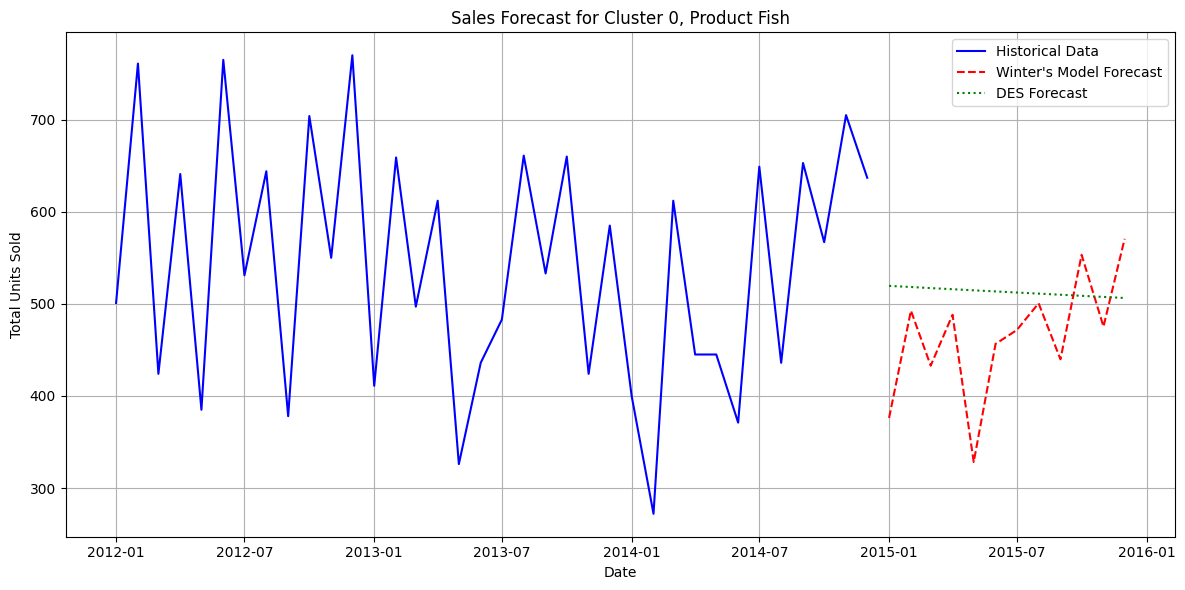

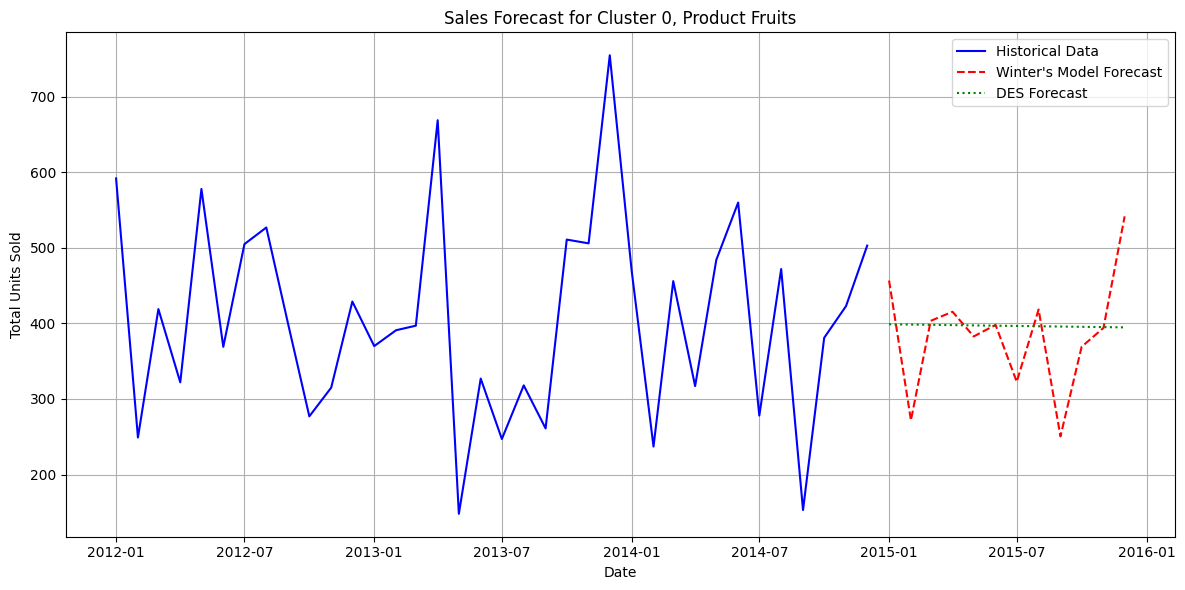

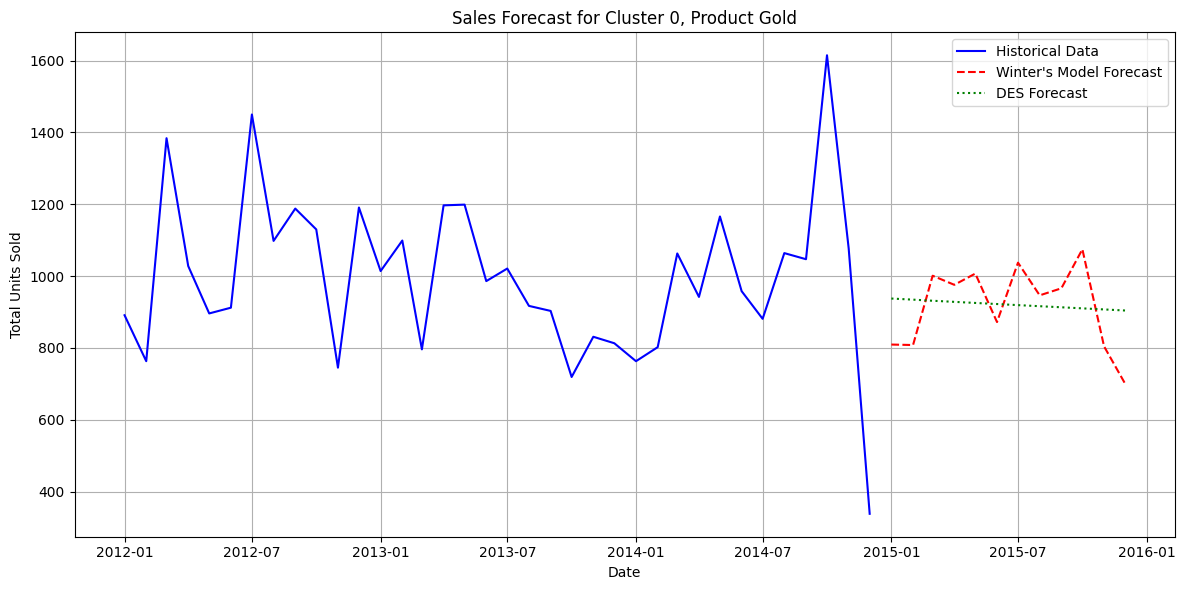

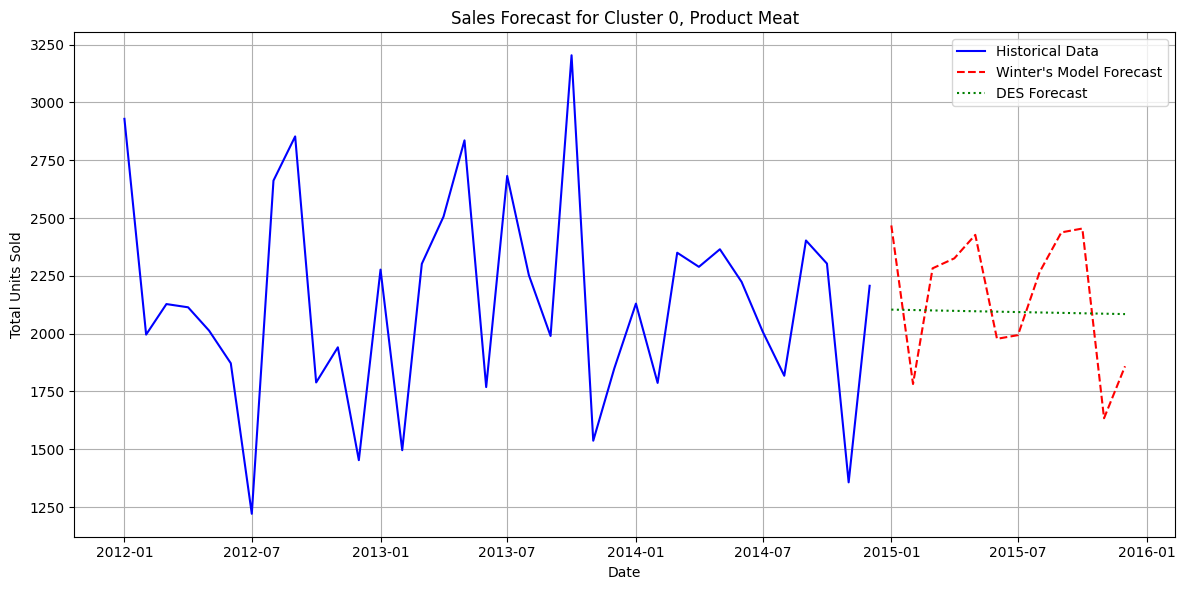

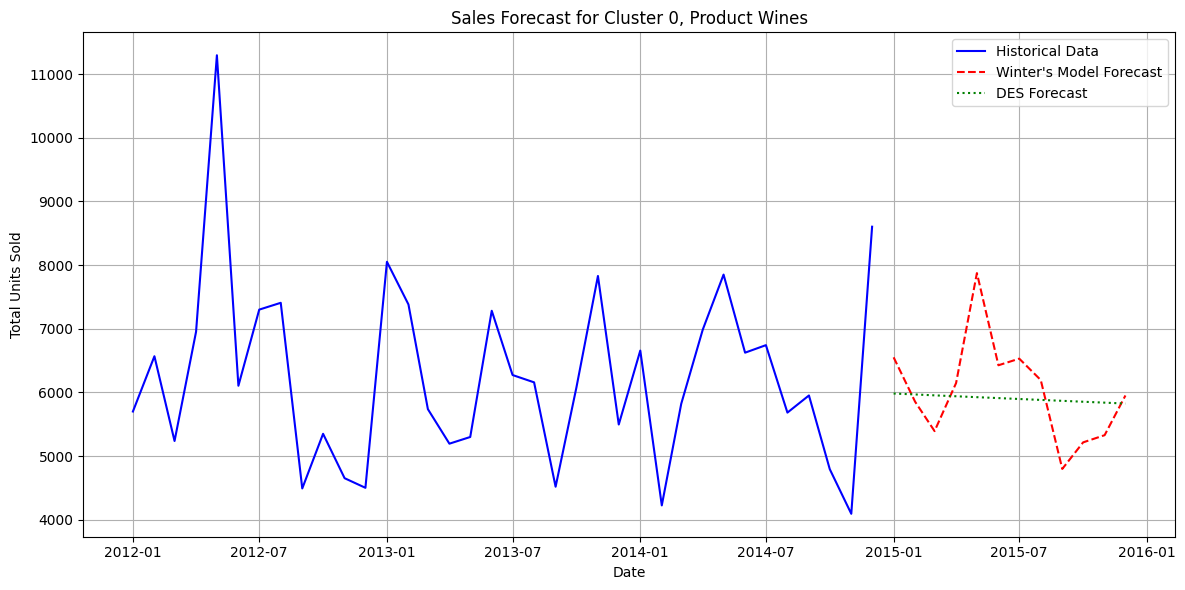

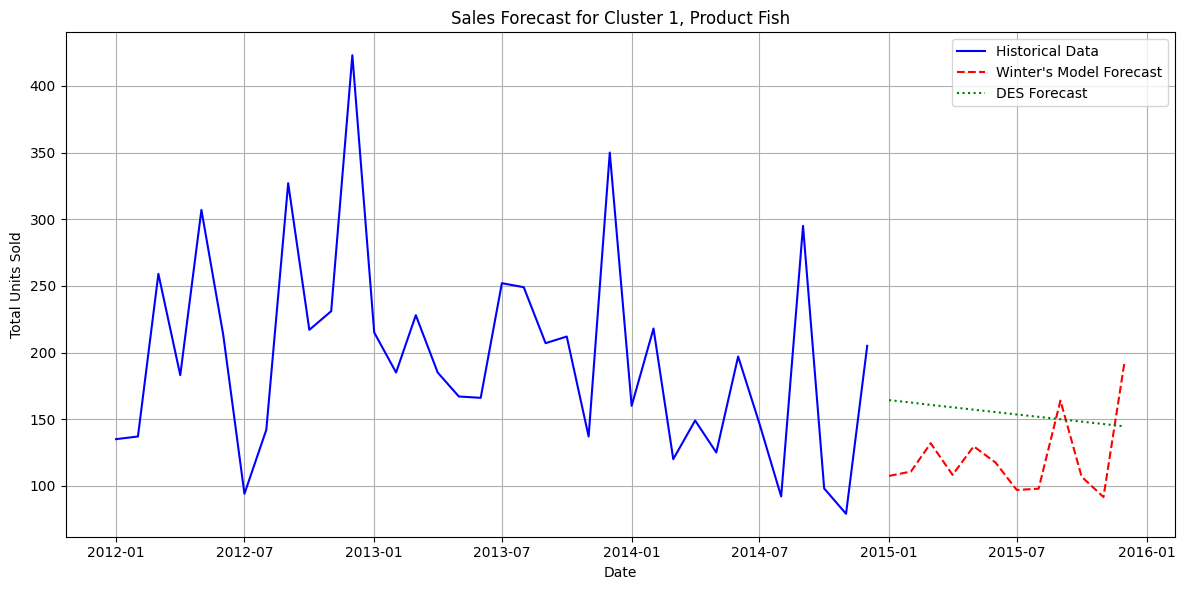

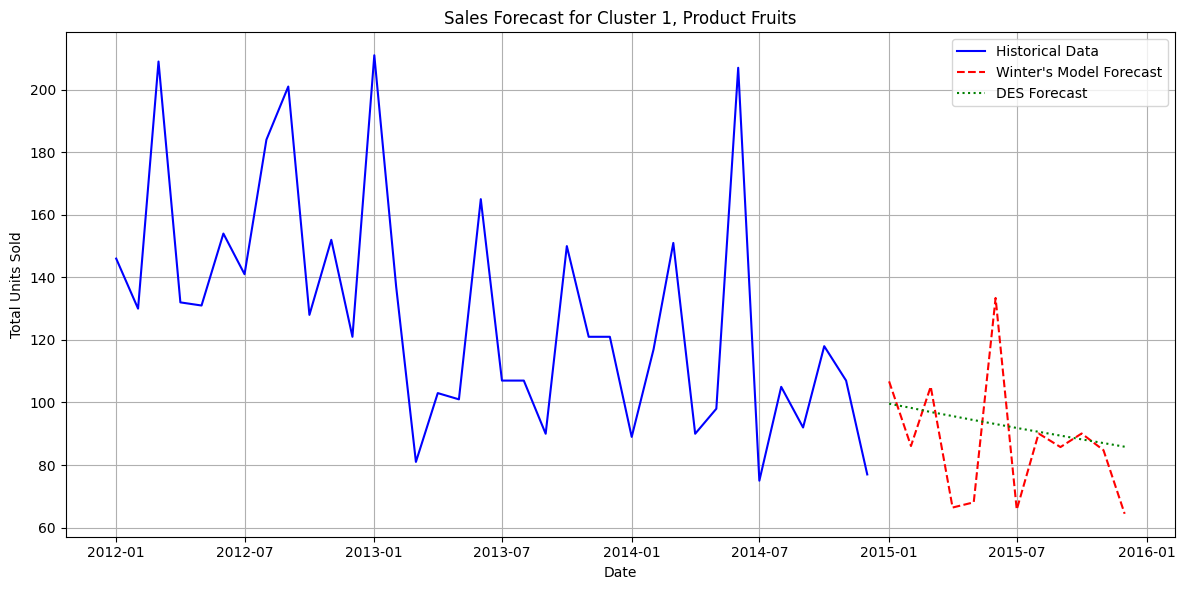

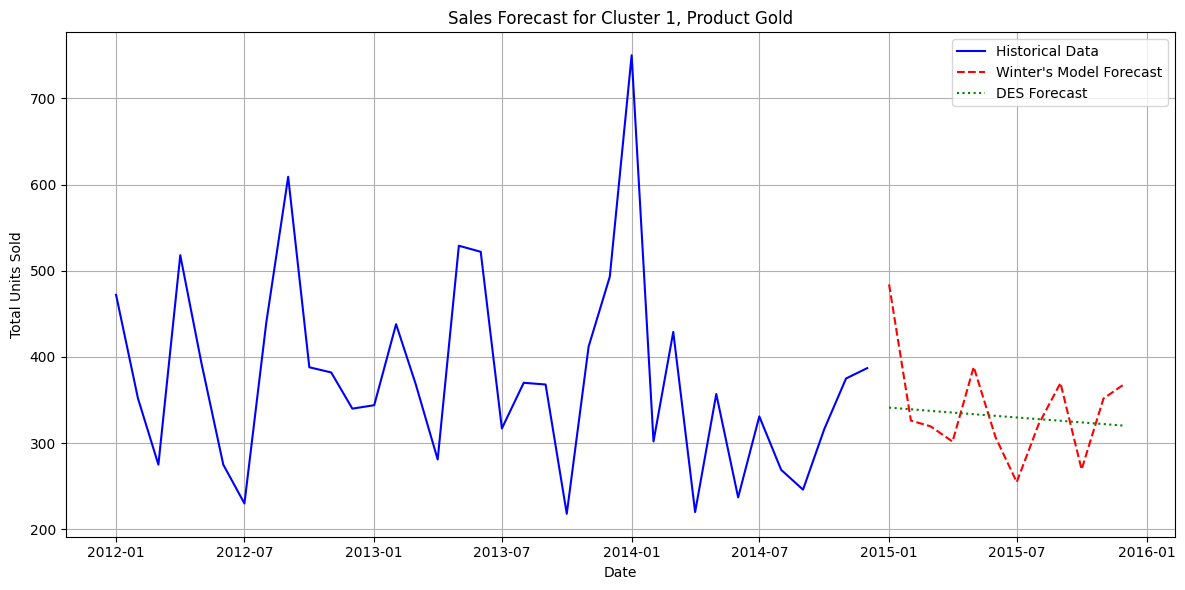

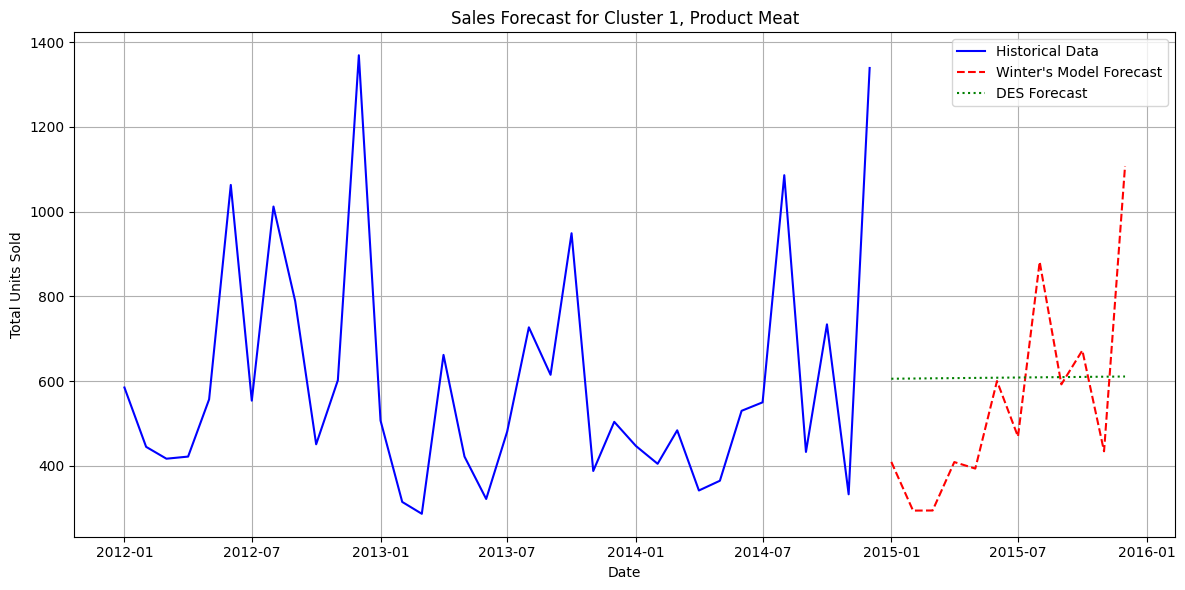

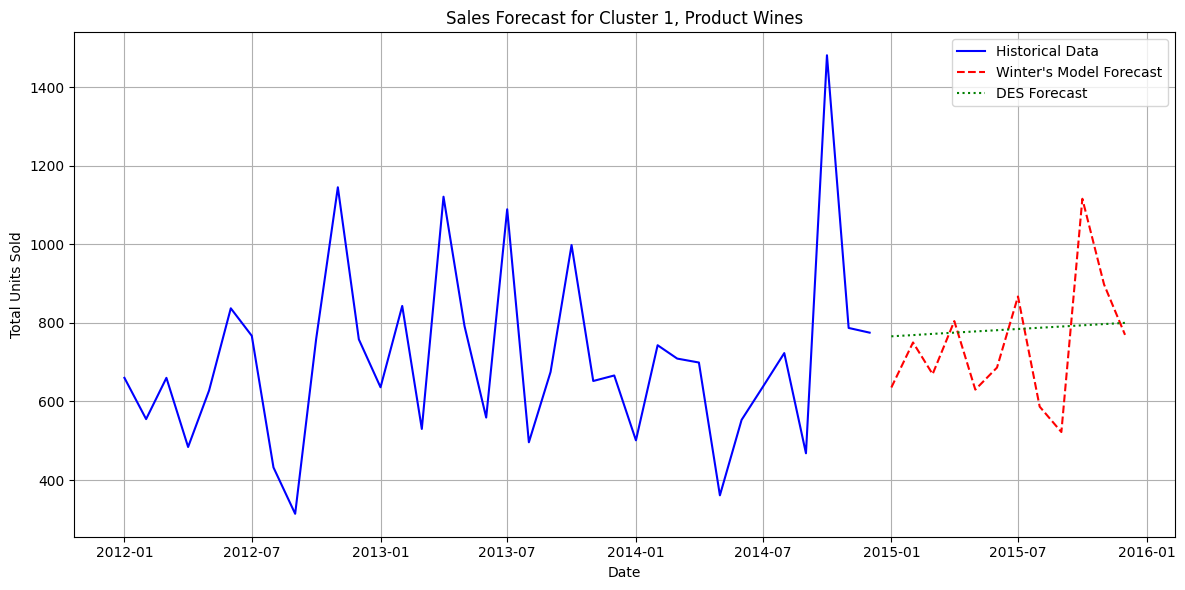

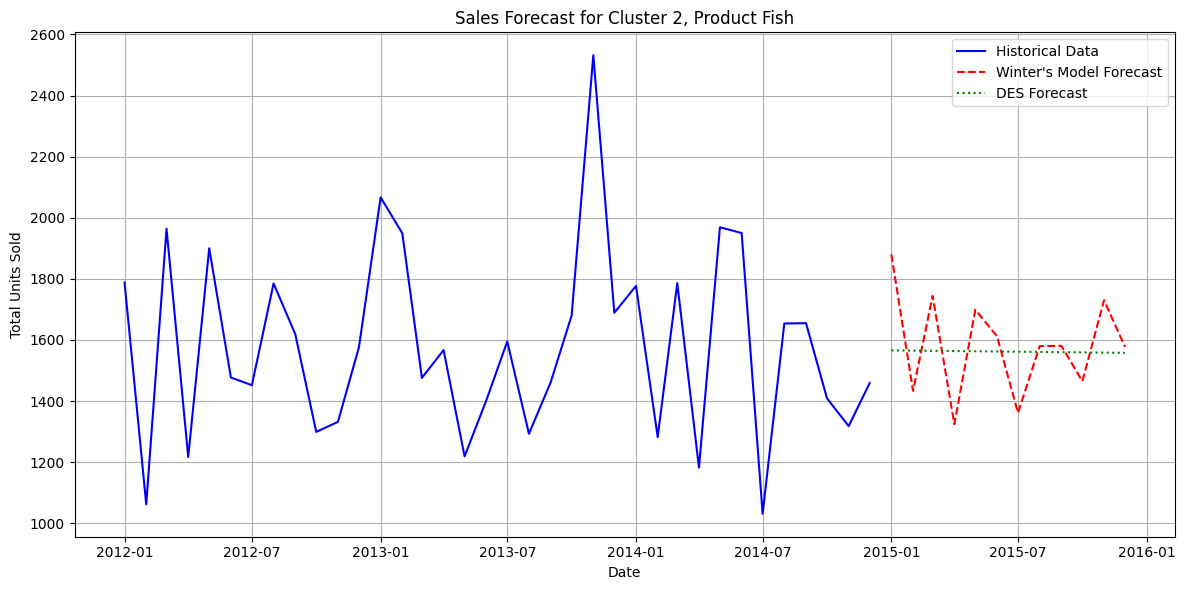

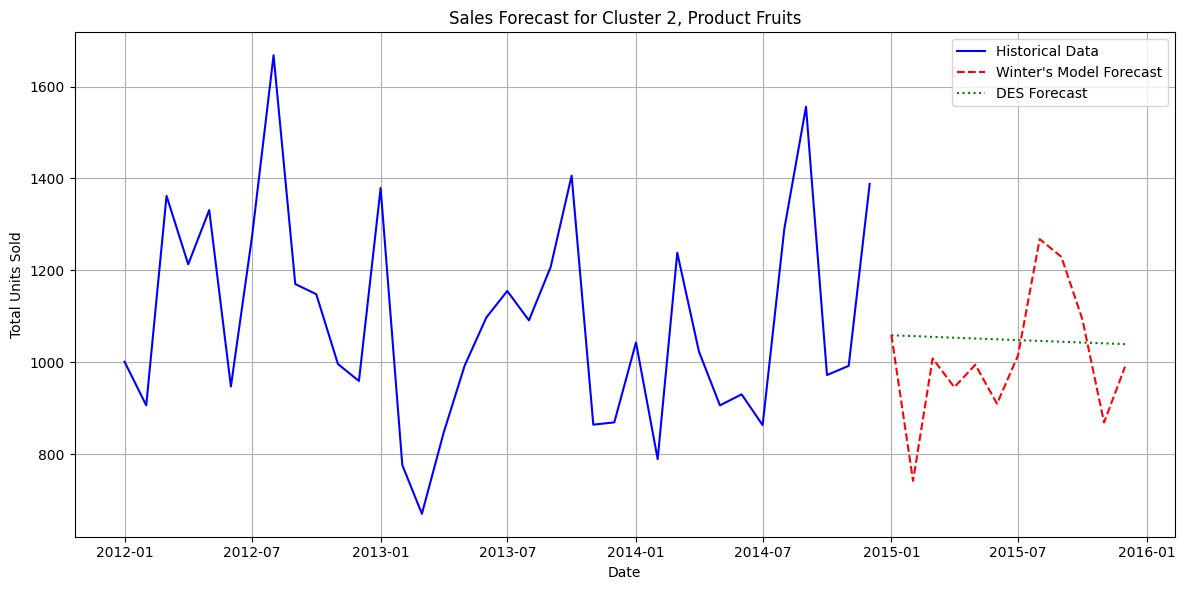

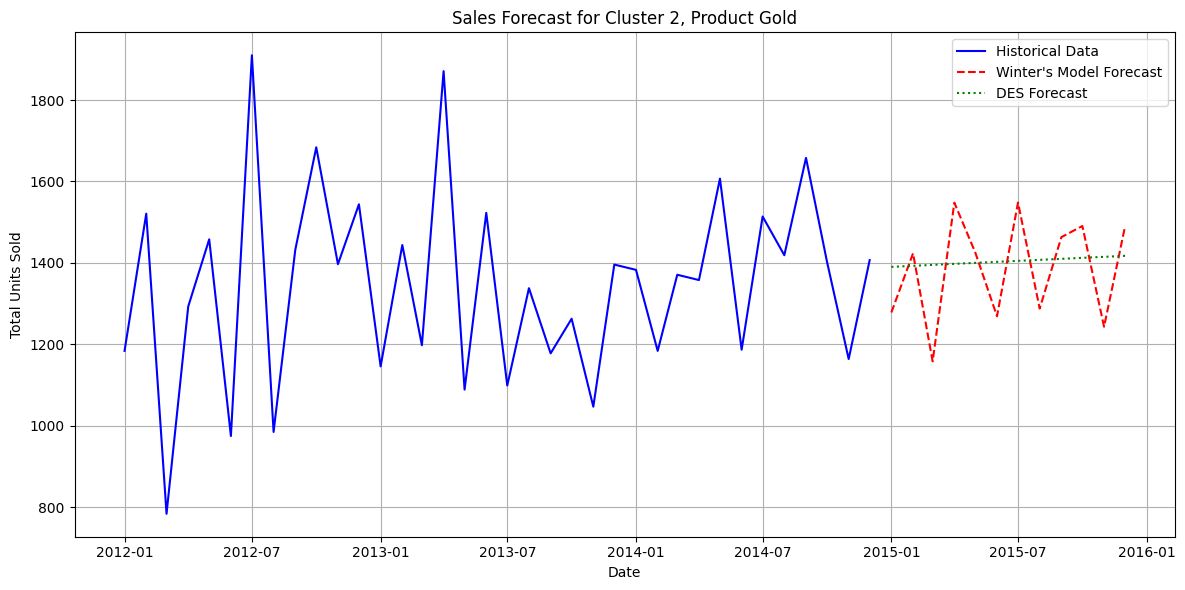

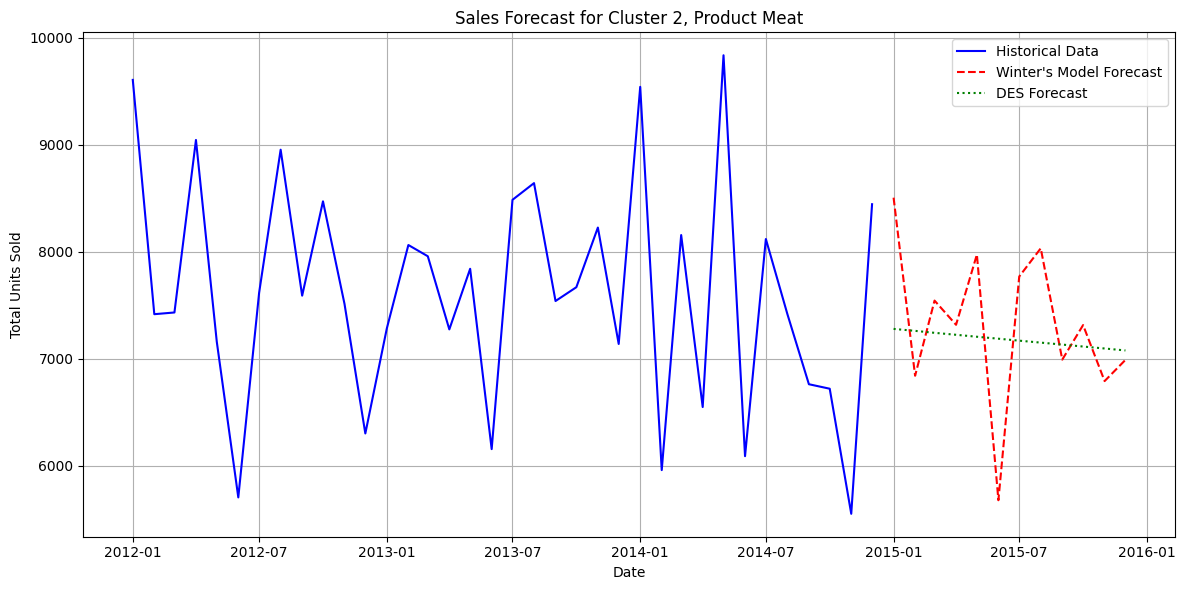

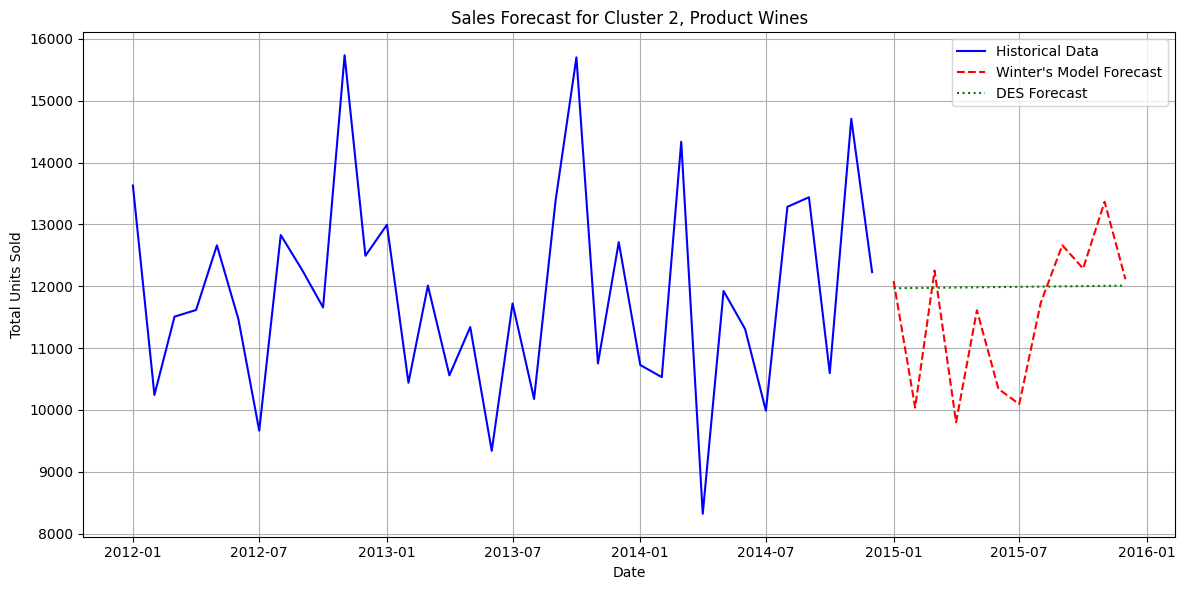

In [14]:
import matplotlib.pyplot as plt

# Loop through each unique combination to create plots
for index, row in unique_combinations.iterrows():
    cluster = row['Cluster_group']
    product = row['Product']

    # Filter historical data for the current combination
    historical_data = monthly_sales[
        (monthly_sales['Cluster_group'] == cluster) &
        (monthly_sales['Product'] == product)
    ]['Total_Units_Sold']

    # Get forecasts for the current combination (Winter's Model)
    winter_forecast = forecasts_2015.get((cluster, product))

    # Get forecasts for the current combination (Double Exponential Smoothing)
    des_forecast = forecasts_2015_des.get((cluster, product))

    # Check if we have data to plot
    if historical_data.empty and winter_forecast is None and des_forecast is None:
        print(f"No data or forecasts available for Cluster: {cluster}, Product: {product}. Skipping plot.")
        continue

    plt.figure(figsize=(12, 6))
    plt.plot(historical_data.index, historical_data.values, label='Historical Data', color='blue')

    if winter_forecast is not None:
        plt.plot(winter_forecast.index, winter_forecast.values, label="Winter's Model Forecast", color='red', linestyle='--')

    if des_forecast is not None:
        plt.plot(des_forecast.index, des_forecast.values, label='DES Forecast', color='green', linestyle=':')

    plt.title(f'Sales Forecast for Cluster {cluster}, Product {product}')
    plt.xlabel('Date')
    plt.ylabel('Total Units Sold')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [15]:
print("\n--- Comparing Forecasts for 2015 ---\n")

# Dictionary to store comparison insights for each combination
comparison_insights = {}

# Loop through each unique combination
for index, row in unique_combinations.iterrows():
    cluster = row['Cluster_group']
    product = row['Product']

    # Get forecasts for the current combination (Winter's Model)
    winter_forecast = forecasts_2015.get((cluster, product))

    # Get forecasts for the current combination (Double Exponential Smoothing)
    des_forecast = forecasts_2015_des.get((cluster, product))

    print(f"\nCluster: {cluster}, Product: {product}")
    print("---------------------------------------")

    if winter_forecast is not None:
        print("Winter's Model Forecasts (2015):")
        print(winter_forecast.to_string())
    else:
        print("Winter's Model: No forecast generated.")

    if des_forecast is not None:
        print("\nDouble Exponential Smoothing Forecasts (2015):")
        print(des_forecast.to_string())
    else:
        print("Double Exponential Smoothing: No forecast generated.")

    # Basic comparison logic
    if winter_forecast is not None and des_forecast is not None:
        diff = winter_forecast - des_forecast
        percentage_diff = (diff / des_forecast) * 100

        insight = {
            'winter_forecast': winter_forecast.tolist(),
            'des_forecast': des_forecast.tolist(),
            'mean_winter': winter_forecast.mean(),
            'mean_des': des_forecast.mean(),
            'std_winter': winter_forecast.std(),
            'std_des': des_forecast.std(),
            'max_diff': diff.max(),
            'min_diff': diff.min(),
            'avg_percentage_diff': percentage_diff.mean()
        }

        print("\n--- Forecast Comparison ---")
        print(f"Mean Winter's Model Forecast: {winter_forecast.mean():.2f}")
        print(f"Mean DES Forecast: {des_forecast.mean():.2f}")
        print(f"Standard Deviation Winter's Model Forecast: {winter_forecast.std():.2f}")
        print(f"Standard Deviation DES Forecast: {des_forecast.std():.2f}")
        print(f"Maximum difference (Winter - DES): {diff.max():.2f}")
        print(f"Minimum difference (Winter - DES): {diff.min():.2f}")
        print(f"Average Percentage Difference (Winter vs DES): {percentage_diff.mean():.2f}%")

        comparison_insights[(cluster, product)] = insight
    else:
        comparison_insights[(cluster, product)] = "Incomplete forecasts"


--- Comparing Forecasts for 2015 ---


Cluster: 0, Product: Fish
---------------------------------------
Winter's Model Forecasts (2015):
2015-01-01    376.130917
2015-02-01    492.652451
2015-03-01    432.875714
2015-04-01    488.117810
2015-05-01    328.218383
2015-06-01    456.567980
2015-07-01    471.473364
2015-08-01    500.605000
2015-09-01    439.816852
2015-10-01    553.269650
2015-11-01    475.313654
2015-12-01    570.646030
Freq: MS

Double Exponential Smoothing Forecasts (2015):
2015-01-01    519.528586
2015-02-01    518.319265
2015-03-01    517.112760
2015-04-01    515.909063
2015-05-01    514.708168
2015-06-01    513.510068
2015-07-01    512.314757
2015-08-01    511.122228
2015-09-01    509.932476
2015-10-01    508.745492
2015-11-01    507.561272
2015-12-01    506.379808
Freq: MS

--- Forecast Comparison ---
Mean Winter's Model Forecast: 465.47
Mean DES Forecast: 512.93
Standard Deviation Winter's Model Forecast: 67.43
Standard Deviation DES Forecast: 4.31
Maximum differe

In [16]:
print("\n--- Average Percentage Difference (Winter's Model vs. DES Forecasts) ---\n")

# Create a list to store the percentage differences
percentage_diff_list = []

for (cluster, product), insight in comparison_insights.items():
    if insight != "Incomplete forecasts":
        percentage_diff_list.append({
            'Cluster_group': cluster,
            'Product': product,
            'Average_Percentage_Difference_Winter_vs_DES': insight['avg_percentage_diff']
        })

# Convert the list to a DataFrame for better display
percentage_diff_df = pd.DataFrame(percentage_diff_list)

# Display the DataFrame
print(percentage_diff_df.to_string(index=False))


--- Average Percentage Difference (Winter's Model vs. DES Forecasts) ---

 Cluster_group Product  Average_Percentage_Difference_Winter_vs_DES
             0    Fish                                    -9.186756
             0  Fruits                                    -2.870704
             0    Gold                                    -0.418028
             0    Meat                                     3.086793
             0   Wines                                     1.967211
             1    Fish                                   -21.066905
             1  Fruits                                    -5.881732
             1    Gold                                     2.326244
             1    Meat                                   -10.215786
             1   Wines                                    -4.969921
             2    Fish                                     1.299496
             2  Fruits                                    -3.661966
             2    Gold                   